In [64]:
import numpy as np
import torch
import torch.nn as nn
from torchvision import transforms
from torchvision.datasets import MNIST
from torchsummary import summary
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

https://pytorch.org/get-started/locally/

In [65]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [66]:
transform = transforms.Compose([transforms.ToTensor()])

trainset = MNIST(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

testset = MNIST(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

In [67]:
trainloader.dataset.data.shape

torch.Size([60000, 28, 28])

In [68]:
testloader.dataset.data.shape

torch.Size([10000, 28, 28])

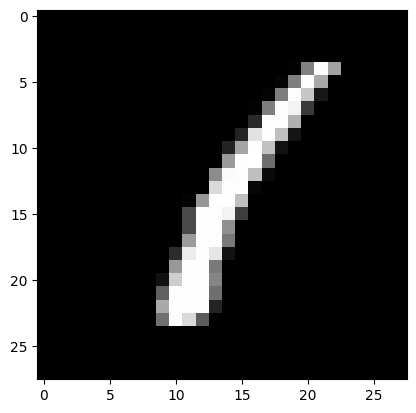

In [144]:
rand_idx_img_train = np.random.randint(low=0, high=60000)
plt.imshow(trainloader.dataset.data[rand_idx_img_train].numpy(), cmap='gray')

In [70]:
class MNISTFCN(nn.Module):
    def __init__(self):
        super(MNISTFCN, self).__init__()
        self.flat = nn.Flatten()

        self.fc1 = nn.Linear(784, 256)
        self.act1 = nn.LeakyReLU(negative_slope=0.01)

        self.fc2 = nn.Linear(256, 128)
        self.act2 = nn.LeakyReLU(negative_slope=0.05)

        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.flat(x)
        x = self.fc1(x)
        x = self.act1(x)
        x = self.fc2(x)
        x = self.act2(x)
        x = self.fc3(x)
        return x

In [96]:
model = MNISTFCN()
model = model.to(device=device)

In [97]:
summary(model, (28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                  [-1, 784]               0
            Linear-2                  [-1, 256]         200,960
         LeakyReLU-3                  [-1, 256]               0
            Linear-4                  [-1, 128]          32,896
         LeakyReLU-5                  [-1, 128]               0
            Linear-6                   [-1, 10]           1,290
Total params: 235,146
Trainable params: 235,146
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 0.90
Estimated Total Size (MB): 0.91
----------------------------------------------------------------


In [98]:
def train(model, loader, criterion, optimizer, num_epoch):
    total_loss = []
    for epoch in tqdm(range(num_epoch)):
        epoch_loss = []
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            epoch_loss.append(loss.item()) # item() т.к. loss - tensor
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
        mean_epoch_loss = np.mean(epoch_loss)
        total_loss.append(mean_epoch_loss)
        print(f'epoch: {epoch + 1} | mean_loss: {mean_epoch_loss}')
    return total_loss, model

In [99]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

In [ ]:
# loss, model = train(model, trainloader, criterion, optimizer, 50)

  2%|▏         | 1/50 [00:08<06:53,  8.43s/it]

epoch: 1 | mean_loss: 0.2813393998899058


  4%|▍         | 2/50 [00:16<06:26,  8.05s/it]

epoch: 2 | mean_loss: 0.10487254588072424


  6%|▌         | 3/50 [00:23<06:05,  7.78s/it]

...

epoch: 48 | mean_loss: 0.0016840050606443877


 98%|█████████▊| 49/50 [06:20<00:07,  7.67s/it]

epoch: 49 | mean_loss: 0.010578838863253736


100%|██████████| 50/50 [06:28<00:00,  7.77s/it]

epoch: 50 | mean_loss: 0.0023180005981954456


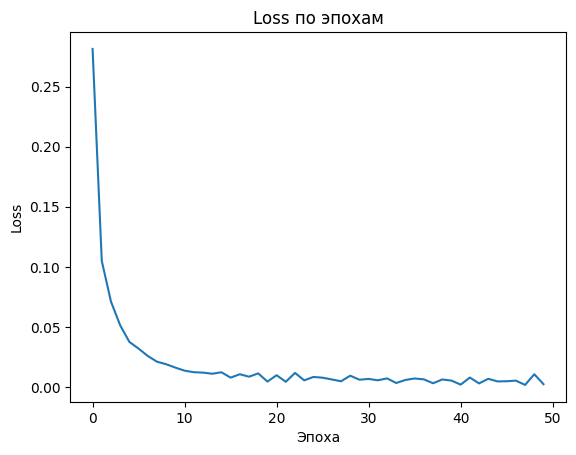

In [ ]:
# plt.plot(loss)
# plt.title('Loss по эпохам')
# plt.xlabel('Эпоха')
# plt.ylabel('Loss')
# plt.show()

In [ ]:
# class_correct = list(0. for i in range(10))
# class_total = list(0. for i in range(10))

# with torch.no_grad():
#     for data in testloader:
#         images, labels = data
#         images = images.to(device)
#         labels = labels.to(device)
#         y_pred = model(images)
#         _, predicted = torch.max(y_pred, 1)
#         c = (predicted.detach() == labels)
#         for i, label in enumerate(labels):
#             class_correct[label] += c[i].item()
#             class_total[label] += 1

In [ ]:
# for i in range(10):
#     print(f'class: {i} | accuracy: {(class_correct[i] / class_total[i] * 100):.2f}%')
# else:
#     print(f'total accuracy: {(sum(class_correct) / sum(class_total) * 100):.2f}%')

class: 0 | accuracy: 98.98%
class: 1 | accuracy: 99.30%
class: 2 | accuracy: 98.16%
class: 3 | accuracy: 98.02%
class: 4 | accuracy: 98.07%
class: 5 | accuracy: 98.65%
class: 6 | accuracy: 98.12%
class: 7 | accuracy: 98.64%
class: 8 | accuracy: 97.13%
class: 9 | accuracy: 98.22%
total accuracy: 98.34%


In [186]:
model_path = './model.pt'

In [ ]:
# torch.save(model.state_dict(), model_path)

In [190]:
loaded_model = MNISTFCN()
loaded_model = loaded_model.to(device)
loaded_model.load_state_dict(torch.load(model_path, weights_only=True))

<All keys matched successfully>

Модель предсказала цифру: 6


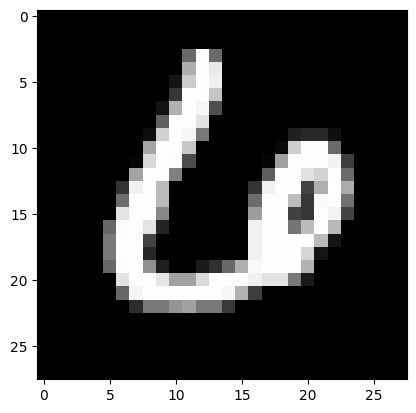

In [195]:
rand_idx_img_test = np.random.randint(low=0, high=10000)
random_img_test = testloader.dataset.data[rand_idx_img_test].numpy()
with torch.no_grad():
    output = loaded_model(transform(random_img_test).to(device))
    _, predicted = torch.max(output, 1)
    predicted_class = predicted.item()
plt.imshow(random_img_test, cmap='gray')
print(f'Модель предсказала цифру: {predicted_class}')